# Trabajo Fin de Máster  
### Análisis de la Ciudad mediante Aprendizaje Supervisado  
#### Detección Automática de Tipologías Residenciales y Patrones de Cerramiento: Interpretabilidad vs Rendimiento

**Master Universitario en Ciencia de Datos e Ingeniería de Computadores (Universidad de Granada)**

> **Autor:** David Fernández Martínez    
> **Email personal:** david.fernxndez.martinez@gmail.com  
> **Email académico:** davidfm8@correo.ugr.es  
> **LinkedIn:** [linkedin.com/in/david-fernández-martínez](https://www.linkedin.com/in/david-fern%C3%A1ndez-mart%C3%ADnez/)  
> **GitHub:** [github.com/davidfernxndez](https://github.com/davidfernxndez)

---

## Análisis de interpretabilidad local: XGBoost vs Regresión logística multinomial

### 📝 Descripción del notebook
En este notebook se realiza un análisis de interpretabilidad local con el objetivo de comprender cómo XGBoost mejora el rendimiento respecto a la regresión logística multinomial mediante la descomposición de predicciones individuales con distintos niveles de dificultad.

### Indice de contenidos
1. [Introducción](#intro)
    * [1.1 Obtención de predicciones y valores SHAP out-of-fold](#out_of_fold)
    * [1.2 Uso de SHAP como herramienta post-hoc](#shap)
    * [1.3 Waterfall plot (Gráfico de cascada)](#waterfall)

2. [Análisis de interpretabilidad local](#analisis)
    * [2.1 Casos de consenso](#consenso)
    * [2.2 Casos de discrepancia](#discrepancia)
    * [2.3 Casos erróneos](#errores)

In [8]:
# jupyter extensions to automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration object
from src.config import cfg

# Estimators to get out-of-fold predictions and shap values
from src.balanced_xgb import BalancedXGBClassifier
from sklearn.linear_model import LogisticRegression

# Method to plot samples in a map
from src.EDA_utils import plot_individual_sample_map

# XAI visualization methods
from src.XAI_utils import (
    # LOCAL SHAP
    get_shap_out_of_fold,
    plot_shap_waterfall,
    plot_misclassification_shap_waterfall
)

**Import troubleshooting**

If the `src` imports fail when running this notebook in a different environment,
uncomment and execute the following cell:

```python
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
# Global configuration
sns.set_theme(style="ticks", context="notebook")
plt.rcParams["font.family"] = "sans-serif"
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore")

In [4]:
# Set descriptive data path to plot samples in a map
descriptive_data_path = os.path.join(cfg.DATA_PROCESSED_DIR, "descriptive_data.csv")

In [5]:
# Reproducibility
SEED = cfg.SEED 
np.random.seed(SEED)
random.seed(SEED)

<a id="intro"></a>
# 1. Introducción

Tras realizar la evaluación de rendimiento y el análisis de interpretabilidad global de todos los modelos considerados en el experimento, se ha concluido que la regresión logística multinomial y XGBoost representan, respectivamente, el mejor modelo transparente y el mejor modelo de caja negra para este problema.

Dado que XGBoost ha sido identificado como el modelo con mayor capacidad predictiva, manteniendo además un nivel de interpretabilidad comparable al de los modelos transparentes, el objetivo de este análisis es estudiar en profundidad cómo resuelve el problema en comparación con un modelo de menor complejidad, como la regresión logística multinomial.

Para ello, se analizan tanto casos en los que ambos modelos coinciden en la predicción correcta como situaciones más complejas en las que XGBoost realiza una clasificación correcta mientras que la regresión logística falla.

<a id="out_of_fold"></a>
## 1.1 Obtención de predicciones y valores SHAP out-of-fold

Tal y como se ha descrito en la sección de metodología, para el análisis de interpretabilidad local se adopta una estrategia de predicción y explicabilidad *out-of-fold*, con el objetivo de aproximar el comportamiento que tendría el modelo en un entorno real de producción frente a datos no observados durante el entrenamiento.

Para ello, se ha desarrollado la función *get_shap_out_of_fold()* en el módulo *src/XAI_utils.py*. Esta función utiliza las particiones generadas durante la Nested Cross Validation y, para cada fold, realiza el siguiente procedimiento:
* El modelo, configurado con los hiperparámetros óptimos obtenidos en la Inner Cross Validation, se entrena exclusivamente con el conjunto de entrenamiento de la partición.
* Se generan las predicciones *out-of-fold* sobre el conjunto de test correspondiente.
* Se calculan los valores SHAP asociados a dichas predicciones.
* Se almacenan los expected values de SHAP correspondientes al modelo entrenado en la partición actual.


A continuación, se aplica  esta función sobre ambos modelos.

In [10]:
XG_model = BalancedXGBClassifier(
        random_state = SEED,
        sampling_method = "uniform",
        objective= "multi:softmax",
        eval_metric="mlogloss",
)
XG_pred_info_df, XG_probabilities_df, XG_shap_values_df, XG_expected_values_df = get_shap_out_of_fold(cfg, XG_model, "XGBoost")



             STARTING PROCESS: OUT-OF-FOLD PREDICTIONS & LOCAL SHAP             
 • Model Name      : XGBoost
 • Outer CV Folds  : 5
--------------------------------------------------------------------------------

[ FOLD 0/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__colsample_bytree  : 0.8
model__gamma             : 0.3
model__learning_rate     : 0.01
model__max_depth         : 5
model__n_estimators      : 300
model__reg_lambda        : 1
model__subsample         : 1.0

Training     | Fitting model... 
Predicting   | Generating out-of-fold predictions... 
SHAP Values  | Explaining via TreeExplainer... 

[ FOLD 1/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__colsample_bytree  : 1.0
model__gamma             : 0
model__learning_rate     : 0.01
model__max_depth         : 5
model__n_estimators      : 300
model__reg_lambda        : 1
model__s

In [11]:
LR_model = LogisticRegression(
    class_weight="balanced",
    solver="lbfgs",
    penalty="l2",
    random_state = SEED
)
LR_pred_info_df, LR_probabilities_df,  LR_shap_values_df, LR_expected_values_df = get_shap_out_of_fold(cfg, LR_model, "Logistic_Regression")


             STARTING PROCESS: OUT-OF-FOLD PREDICTIONS & LOCAL SHAP             
 • Model Name      : Logistic_Regression
 • Outer CV Folds  : 5
--------------------------------------------------------------------------------

[ FOLD 0/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__C                 : 10

Training     | Fitting model... 
Predicting   | Generating out-of-fold predictions... 
SHAP Values  | Explaining via LinearExplainer... 

[ FOLD 1/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__C                 : 10000

Training     | Fitting model... 
Predicting   | Generating out-of-fold predictions... 
SHAP Values  | Explaining via LinearExplainer... 

[ FOLD 2/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__C                 : 100

Training     | Fitting model... 


<a id="shap"></a>
## 1.2 Uso de SHAP como herramienta post-hoc

Para realizar este análisis se emplea la técnica de interpretabilidad post-hoc SHAP (SHapley Additive exPlanations) con el objetivo de disponer de un marco de interpretación común para la comparación entre los modelos. SHAP permite cuantificar la contribución individual de cada variable a la predicción realizada para una muestra concreta, proporcionando explicaciones locales comparables independientemente del algoritmo.

Cabe destacar que los valores SHAP obtenidos para cada modelo se encuentran en la escala "raw" propia de cada uno:
* Regresión logística multinomial. Los valores SHAP se expresan en el espacio de log-odds, es decir, en el valor previo a la aplicación de la función sigmoide utilizada para calcular las probabilidades.
* XGBoost. los valores SHAP se representan en el espacio de scores o predicciones crudas, antes de aplicar la función softmax para obtener las probabilidades finales.

Dado que estas escalas son inherentes a cada modelo, las magnitudes de los valores SHAP no son directamente comparables entre sí. No obstante, puesto que el objetivo del análisis es explicar predicciones concretas para comprender cómo cada modelo toma sus decisiones, los valores SHAP se interpretan de forma relativa dentro de cada modelo, por lo que esta diferencia de escala no supone una limitación. En consecuencia, el análisis se centra en:
* El signo de las contribuciones, es decir, si una variable influye positiva o negativamente en la predicción.
* El ranking de importancia de las variables.
* La forma en la que cada modelo distribuye las contribuciones entre las variables.

Aunque sería posible transformar los valores SHAP al espacio de probabilidades para comparar  también las magnitudes en igualdad de condiciones, dicha transformación rompería las propiedades aditivas de SHAP, dificultando tanto el análisis visual como la interpretabilidad de las predicciones.

<a id="waterfall"></a>
## 1.3 Waterfall plot (Gráfico de cascada)

Para interpretar las predicciones individuales realizadas por los modelos, se emplea el gráfico de cascada o waterfall plot de la librería shap. Esta representación visual descompone una predicción en las contribuciones aditivas de cada variable, mostrando cómo cada característica desplaza progresivamente la salida del modelo desde un valor base hasta la predicción final.

En el gráfico, el valor base o expected value aparece representado en la parte inferior del eje de abscisas como $E[f(x)]$. Este valor representa la salida esperada del modelo para la clase analizada cuando no se dispone de información sobre ninguna variable de entrada; es decir, la predicción que el modelo realizaría “a ciegas”. A partir de este punto, el gráfico muestra cómo las contribuciones individuales de las variables modifican progresivamente la salida del modelo hasta alcanzar la predicción final, representada como $f(x)$ en la parte superior del gráfico.

En el waterfall plot, las variables aparecen ordenadas según la magnitud absoluta de su contribución, lo que permite identificar fácilmente qué características han tenido una mayor influencia en la decisión del modelo y en qué dirección lo han hecho: empujando la predicción hacia la clase analizada (contribución positiva) o alejándola de ella (contribución negativa).

Cabe destacar que, dado que se ha seguido una estrategia de predicción y explicabilidad *out-of-fold*, cada muestra ha sido predicha utilizando el modelo correspondiente al fold al que pertenece. En consecuencia, el expected value (valor base) de SHAP presenta variaciones entre *folds*, ya que cada modelo ha sido entrenado sobre un conjunto de entrenamiento diferente y configurado con los hiperparámetros óptimos obtenidos para dicha partición.

Con el objetivo de garantizar la trazabilidad del análisis, el título de cada gráfico especifica el *fold* asociado a la muestra analizada. De este modo, cada explicación de interpretabilidad local puede asociarse con el modelo concreto utilizado para generar la predicción y obtener los valores SHAP.

<a id="analisis"></a>
# 2. Análisis de interpretabilidad local

Dado que el análisis de interpretabilidad local consiste en diseccionar y explicar predicciones individuales, se ha seleccionado un conjunto representativo de casos que permite extraer conclusiones e información de valor sobre el comportamiento de XGBoost. Para ello, el análisis se divide en tres casuísticas principales:

* **Casos de consenso (acierto mutuo)**. Analizar si, en aquellas instancias correctamente clasificadas por ambos modelos, las explicaciones obtenidas comparten una lógica interpretativa similar o, por el contrario, los modelos siguen “caminos” diferentes para alcanzar la misma clasificación.
* **Casos de discrepancia**. Analizar cómo XGBoost consigue clasificar correctamente aquellas observaciones en las que la regresión logística comete un error. Este análisis resulta especialmente relevante para evaluar si los aciertos de XGBoost en los casos de mayor complejidad se sustentan en relaciones coherentes con el conocimiento del dominio o si, por el contrario, carecen de una lógica interpretativa consistente.
* **Casos erróneos**. Analizar las instancias más conflictivas en las que ambos modelos realizan una clasificación incorrecta. En este caso, el análisis se centra en XGBoost, al tratarse del modelo con mayor capacidad predictiva, mediante la comparación del gráfico *waterfall* asociado tanto a la clase real como a la clase predicha erróneamente. De este modo, se pretende identificar qué variables alejan la predicción de la clase correcta y cuáles impulsan al modelo hacia la clase incorrecta.

In [8]:
# Load descriptive data to use LAT, LON and MUN variables to plot residential complex in the map
descriptive_data_df = pd.read_csv(descriptive_data_path)

In [9]:
# Join both predictions dataframes to compare specficic predictions
compare_pred_df = LR_pred_info_df.rename(columns={'URB_pred':'URB_LR', 'prob':'prob_LR'}).copy()
compare_pred_df = pd.merge(
    compare_pred_df,
    XG_pred_info_df[['URB_pred','prob','CC']].rename(columns={'URB_pred':'URB_XG', 'prob':'prob_XG'}),
    how="left",
    on="CC"
)

<a id="consenso"></a>
## 2.1 Casos de consenso

Se han analizado múltiples casos de consenso entre ambos modelos y se ha observado que existen dos casuísticas en función del grado de cerramiento. En los grados de cerramiento "Protegido", "Autoaislado" e "Individualista" existe una alta concistencia en las variables que utilizan ambos modelos para realizar la clasificación. Por el contrario, en los grados de cerramiento "Controlado" y "Simbólico" existen casos en los que los modelos llegan a la misma clasificación utilizando información distinta.

In [10]:
# Select succesfull cases in both models
succes_cases_df = compare_pred_df[
    (compare_pred_df["URB_LR"]==compare_pred_df["URB"]) &
    (compare_pred_df["URB_XG"]==compare_pred_df["URB"])

].copy().reset_index(drop=True)

A conitnuación se analiza el complejo residencial "Autoaislado" cuyo CC es 4701004 como ejemplo representativo de una explicabilidad consistente entre los modelos.

Este complejo residencial se caracteriza por estar integrado en el núcleo úrbano (**DIS_3=0**), por tener un elemento disuasorio como las calles en fondo de saco (**CFS=1**) y disponer de dominio y uso público de la vía (**PPU=1**).

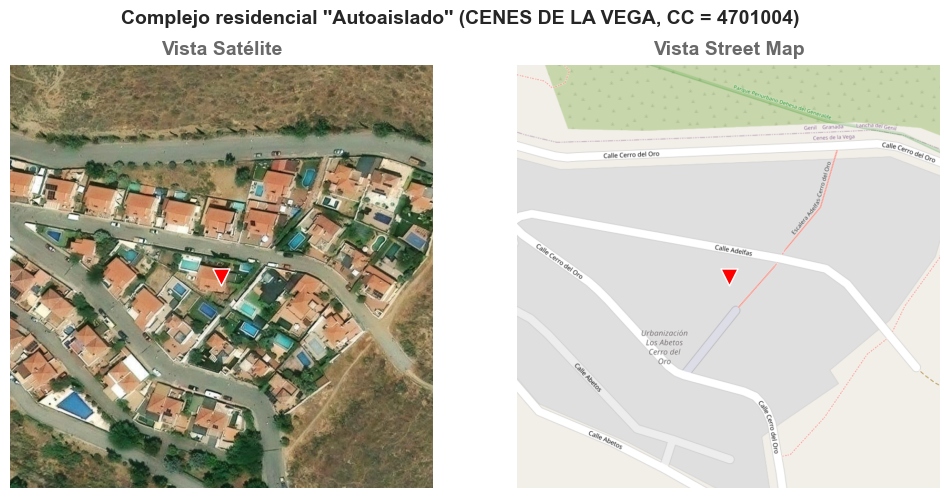

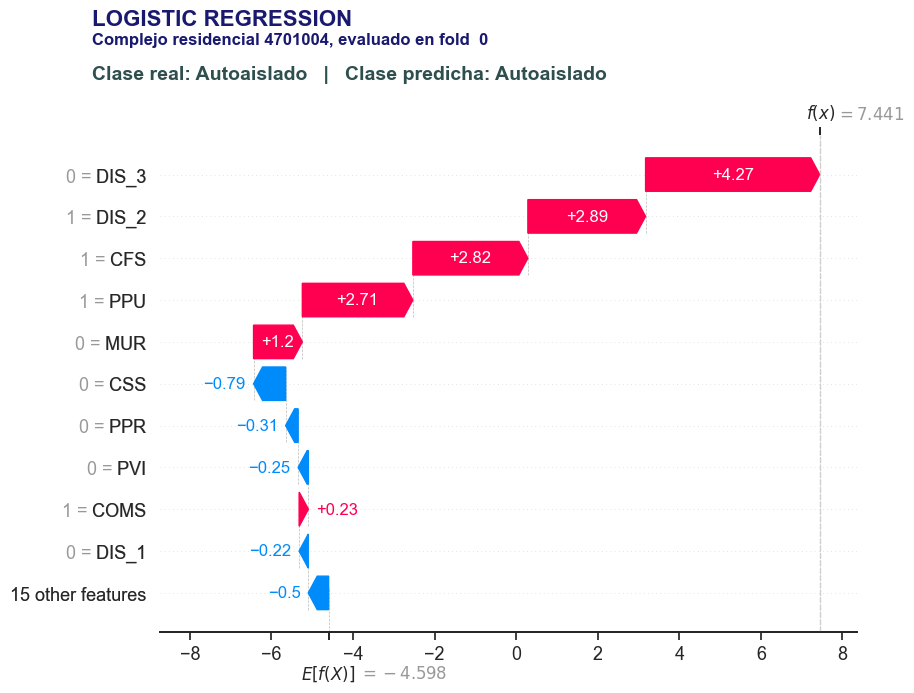

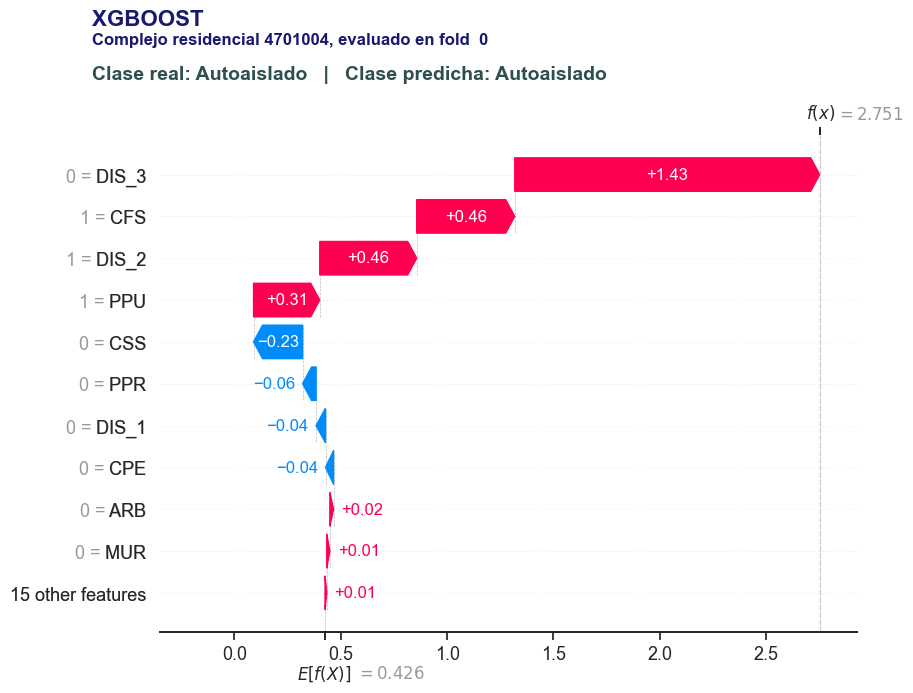

In [12]:
id_sample = 4701004
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=120, figsize=[12,6])
plot_shap_waterfall(cfg, LR_pred_info_df, LR_expected_values_df, LR_shap_values_df, id_sample=id_sample, model_name="Logistic Regression", figsize=[9,7])
plot_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

Como puede observarse en los gráficos *waterfall*, las clasificaciones realizadas por ambos modelos presentan una explicabilidad basada principalmente en las variables **DIS_3**, **DIS_2**, **CFS** y **PPU**. La ausencia de calles sin salida (**CSS**) y de uso privado de la vía (**PPR**) penaliza en ambos modelos puesto que son elementos que contribuyen a este grado de cerramiento.

Este complejo residencial queda caracterizado de forma coherente con el patrón identificado durante el análisis de interpretabilidad global, en el que el grado de cerramiento “Autoaislado” ha sido definido como complejos residenciales aislados del núcleo úrbano, con algún elemento disuasorio y con un uso de la vía que puede ser público o privado. Puede concluirse que se trata de una muestra que se alinea con la estructura general aprendida por el modelo para esta categoría.

A continuación, se analizan las predicciones de dos complejos residenciales pertenecientes a los grados de cerramiento “Controlado” y “Simbólico”, en los que las explicaciones de los modelos presentan ligeras diferencias.

En primer lugar, se estudia el complejo residencial “Controlado”, cuyo identificador CC es 8709023. Este complejo se caracteriza por la ausencia de cámaras de seguridad (**CSE = 0**), la presencia de varios accesos comunitarios y la ausencia de accesos por bloque o vivienda (**COMS = 1, PVI = 0, PBL = 0**). Además, se encuentra integrado en el núcleo urbano (**DIS_3 = 1**) y dispone de comercios externos asociados (**LEX = 1**).

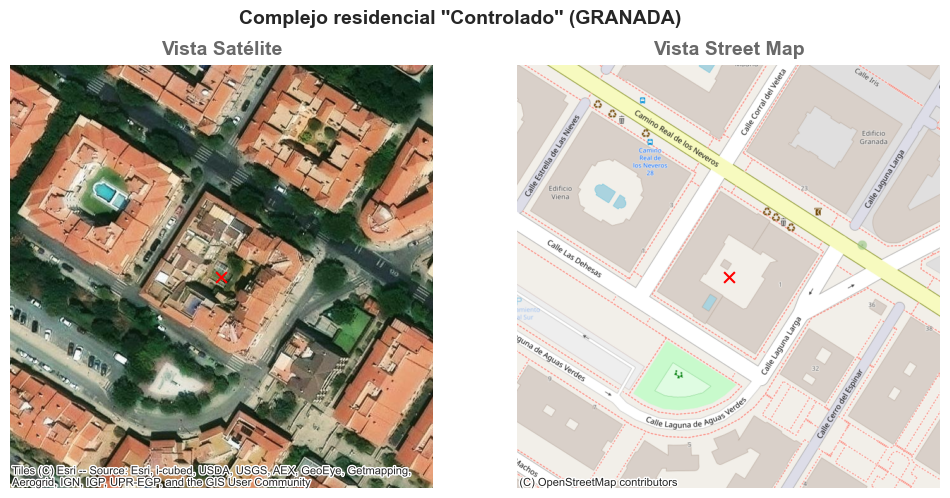

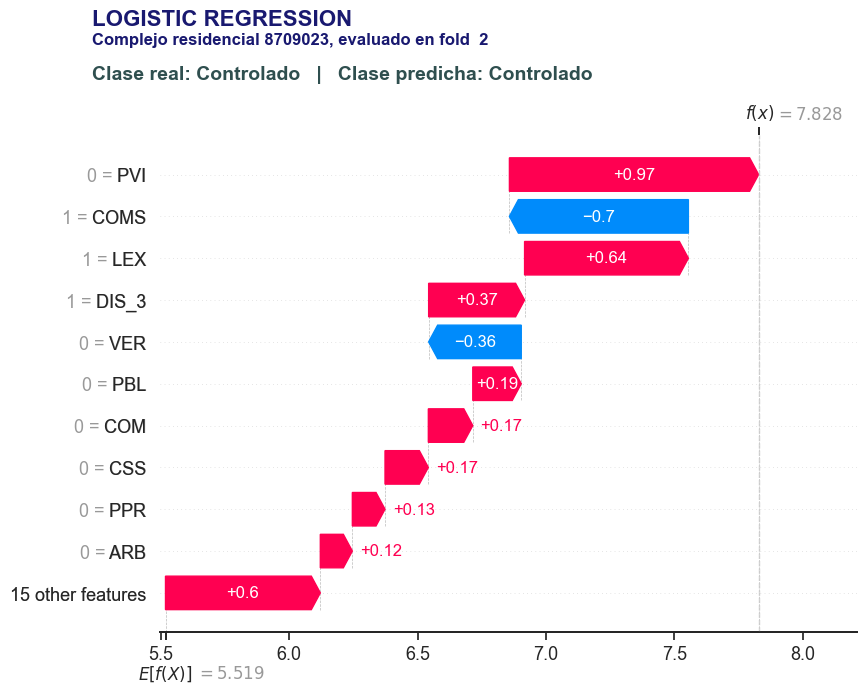

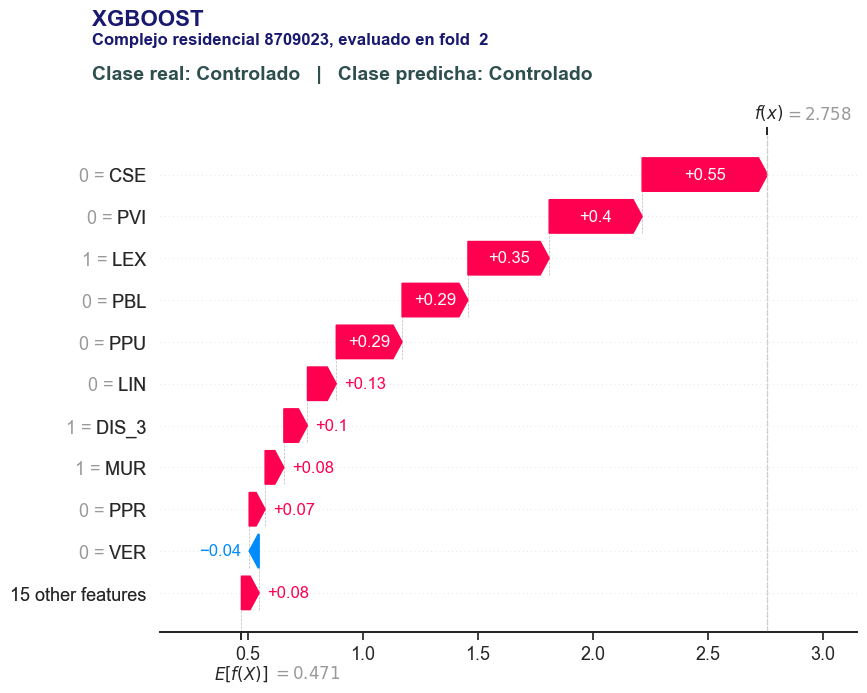

In [12]:
id_sample = 8709023
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=100, figsize=[12,6])
plot_shap_waterfall(cfg, LR_pred_info_df, LR_expected_values_df, LR_shap_values_df, id_sample=id_sample, model_name="Logistic Regression", figsize=[9,7])
plot_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

La principal diferencia entre ambos modelos reside en que la ausencia de cámaras de seguridad tiene una influencia muy baja en la regresión logística (no aparece entre las 10 variables más relevantes), mientras que en XGBoost es la variable con mayor contribución a la salida del modelo.

En la regresión logística, la explicabilidad de esta predicción se apoya en la ausencia de acceso por vivienda (**PVI = 0**), la presencia de comercios externos (**LEX = 1**) y la integración en el núcleo urbano (**DIS_3 = 1**). En conjunto, estas variables proporcionan una explicación más limitada de la predicción.

Sin embargo, en el caso de XGBoost, la predicción se distribuye de forma más equilibrada entre varias variables, destacando la ausencia de cámaras de seguridad (**CSE = 0**), la ausencia de acceso por bloque o vivienda (**PBL = 0, PVI = 0**), la presencia de comercios externos (**LEX = 1**) y la ausencia de uso público de la vía (**PPU = 0**). En conjunto estas variables aportan una interpretación más solida respecto a la caracterización global del grado de cerramiento "Protegido". En este complejo residencial conviven elementos asociados a un cerramiento alto que quedan matizados o reducidos por la presencia de comercios externos y la ausencia de sistemas de seguridad y vigilancia.

Al tratarse de un grado de cerramiento muy similar a “Protegido”, una explicabilidad más distribuida entre variables, y que además incorpora información del bloque de seguridad y de uso de la vía, permite una explicabilidad basada en variables que caracterizan a estos grados de cerramiento y por tanto comprender por que es "Controlado" y no "Protegido". 

A continuación, se analiza el complejo residencial “Simbólico”, cuyo identificador es CC = 8401006, en el que las diferencias observadas entre la forma en que ambos modelos obtienen la predicción se explican principalmente por la arquitectura interna de cada uno.

Este complejo residencial se caracteriza por estar integrado en el núcleo urbano (**DIS_3 = 1**), presentar uso público de la vía (**PPU = 1**) y no contar con cerramientos de tipo duro como muros (**MUR = 0**) o verjas (**VER = 0**). Estas características son coherentes con el patrón general identificado en el análisis de interpretabilidad global para el grado de cerramiento "Simbólico". No obstante, el complejo también incorpora elementos disuasorios como calles sin salida (**CSS = 1**) y calles en fondo de saco (**CFS = 1**). 

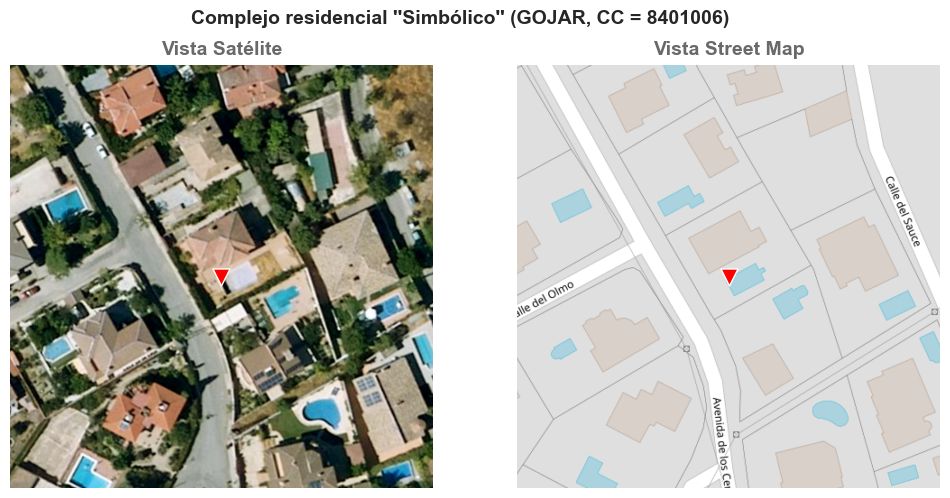

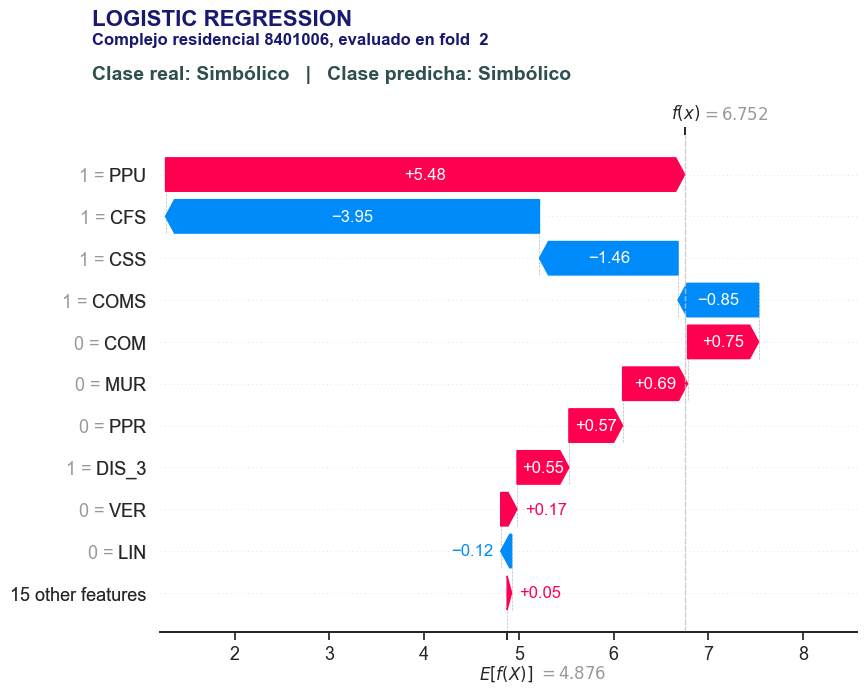

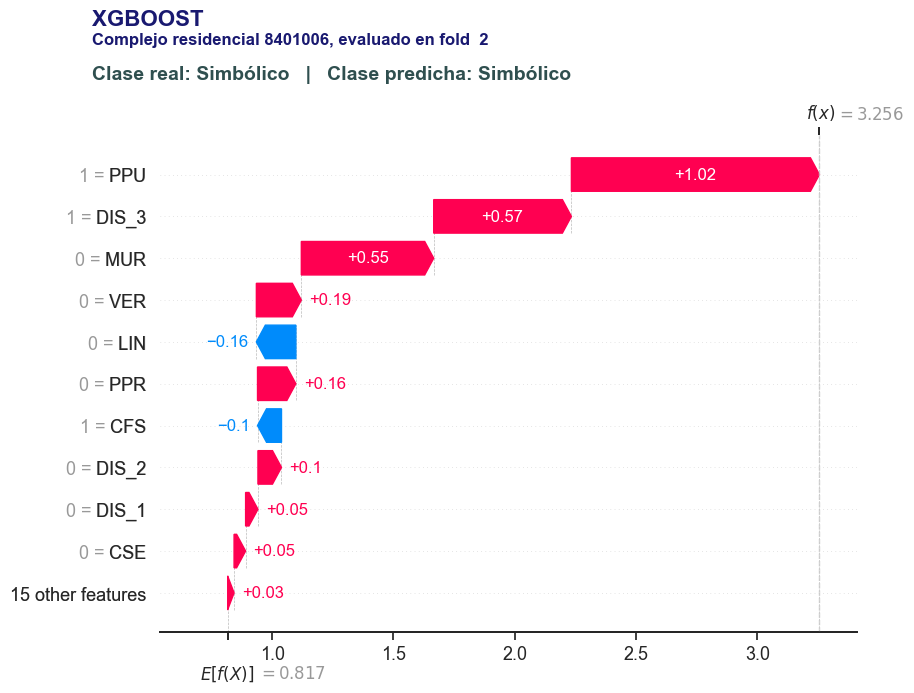

In [11]:
id_sample = 8401006
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=70, figsize=[12,6])
plot_shap_waterfall(cfg, LR_pred_info_df, LR_expected_values_df, LR_shap_values_df, id_sample=id_sample, model_name="Logistic Regression", figsize=[9,7])
plot_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

En la regresión logística multinomial, el gráfico *waterfall* revela que la variable de uso público de la vía (**PPU**) aporta la principal contribución positiva hacia la clase "Simbólico" y que las calles sin salida (**CSS**) y calles en fondo de saco (**CFS**) actúan como fuertes factores inhibidores. En consecuencia, la explicación obtenida con este modelo resulta más difusa, ya que una parte significativa de la decisión se fundamenta en variables que penalizan la predicción, en lugar de características que definan de forma clara la identidad del grado de cerramiento.

En contraposición, XGBoost proporciona una interpretación más nítida y descriptiva. En este caso, la predicción se concentra principalmente en la contribución positiva de las variables **PPU**, **DIS_3**, **MUR** y **VER**. A partir de estas variables, puede interpretarse que el complejo residencial presenta una intensidad de cerramiento muy sutil, caracterizada por la ausencia de cerramientos físicos de tipo duro, su integración en el núcleo urbano y el uso público de la vía.

Esta diferencia en la forma de realizar la clasificación se explica por la naturaleza matemática de ambos algoritmos. La regresión logística multinomial modela la relación entre variables y clases mediante coeficientes globales fijos para cada par variable–clase. Las variables **CSS** y **CFS** presentan una fuerte asociación con la clase "Autoaislado", lo que se traduce en coeficientes altos para dicha clase. Debido a la estructura lineal aditiva de la regresión logística, estos mismos coeficientes contribuyen de forma implícita a reducir la probabilidad de las clases restantes cuando dichas variables están presentes.

Como consecuencia, cuando **CSS** y **CFS** aparecen en complejos residenciales que pertenecen a otras clases, actúan como factores que penalizan la salida del modelo, tal y como reflejan los valores SHAP. Este efecto puede llegar a condicionar la predicción final si no existen otras variables con suficiente peso que refuercen la clase real.

En cambio, XGBoost construye la predicción mediante árboles de decisión capaces de modelar relaciones no lineales y dependientes del contexto local. Esto permite que variables como **CSS** o **CFS** únicamente tengan un peso relevante en determinadas regiones del espacio de características. En consecuencia, cuando estas variables no aportan información discriminativa significativa, el modelo reduce su influencia en la predicción. 

Como resultado, el gráfico *waterfall* de XGBoost ofrece una explicación más coherente con la semántica urbanística de esta categoría, ya que la decisión se apoya principalmente en variables verdaderamente representativas de la clase predicha.

Este ejemplo muestra que, incluso en situaciones en las que ambos modelos aciertan la predicción, el uso de XGBoost resulta ventajoso, ya que permite explotar interacciones más complejas entre variables. En consecuencia, las explicaciones obtenidas son más ricas y están mejor alineadas con el conocimiento del dominio.

Tras el análisis de los casos de consenso entre ambos modelos, puede concluirse que, en aquellos complejos residenciales que se ajustan de forma más clara al patrón general de su clase, como ocurre generalmente en los grados de cerramiento "Protegido", “Autoaislado” e "Individualista", caracterizados por un conjunto de variables altamente discriminativas, ambos modelos tienden a comportarse de manera muy similar en términos de explicabilidad.

Por el contrario, en aquellos grados de cerramiento en los que los patrones de clase son más difusos o menos definidos, sí se observan diferencias relevantes en la explicabilidad, las cuales responden a la naturaleza interna de cada algoritmo. En estos casos, aunque ambos modelos alcancen la misma predicción correcta, XGBoost es capaz de proporcionar una explicabilidad de mayor calidad, al capturar interacciones más complejas entre variables y ofrecer descomposiciones más coherentes con el conocimiento del dominio.

<a id="discrepancia"></a>
## 2.2 Casos de discrepancia

En esta sección se analizan aquellos casos en los que la regresión logística multinomial comete errores de clasificación, mientras que XGBoost realiza una predicción correcta. Estos ejemplos ponen de manifiesto que, en situaciones de mayor complejidad, en las que las características del complejo residencial se desvían de los patrones más generales de su grado de cerramiento, XGBoost es capaz de modelar de forma más adecuada los patrones especificos de esos casos y clasificar correctamente.

Para ello, se han seleccionado tres ejemplos representativos de este comportamiento.

In [12]:
# Select cases where XG succes and LR fails
XG_succes_cases_df = compare_pred_df[
    (compare_pred_df["URB_LR"]!=compare_pred_df["URB"]) &
    (compare_pred_df["URB_XG"]==compare_pred_df["URB"])

].copy().reset_index(drop=True)

El primer caso corresponde a un complejo residencial "Controlado", cuyo identificador CC es 8703071. Este complejo se caracteriza por estar integrado en el núcleo urbano (**DIS_3 = 1**), disponer de acceso por bloque (**PBL = 1**), contar con cámaras de seguridad (**CSE = 1**) y presentar comercios externos (**LEX = 1**).

En este caso, la regresión logística multinomial realiza una clasificación incorrecta, asignando la muestra a la categoría “Simbólico”.

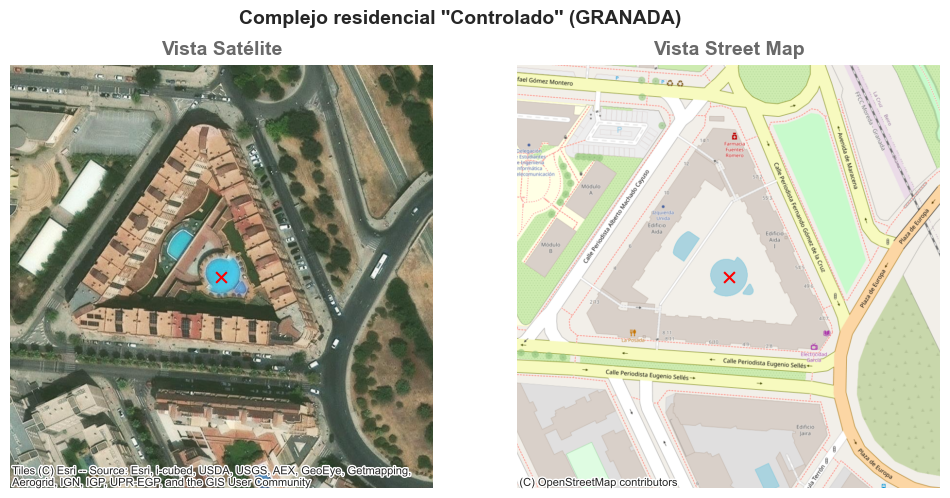

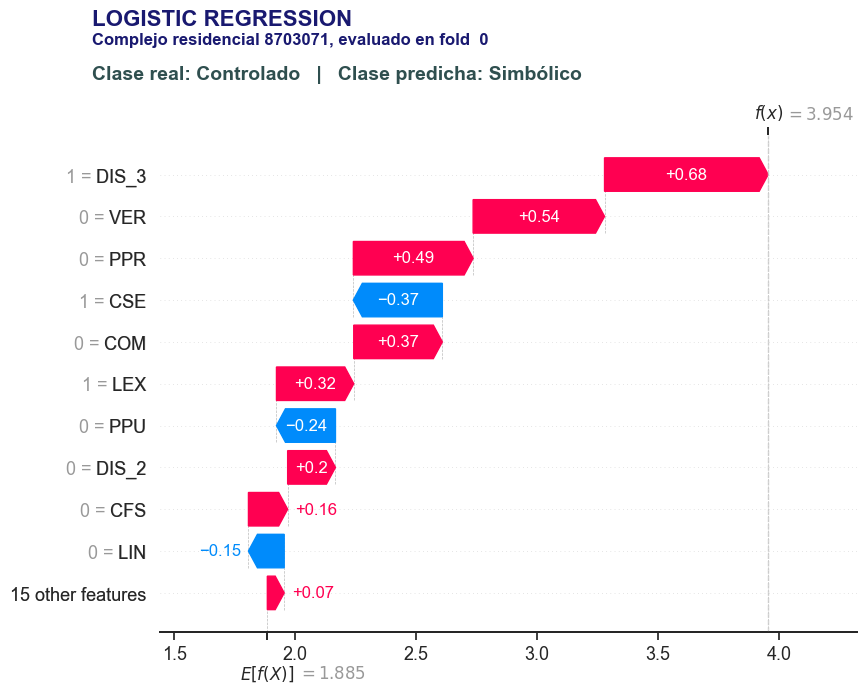

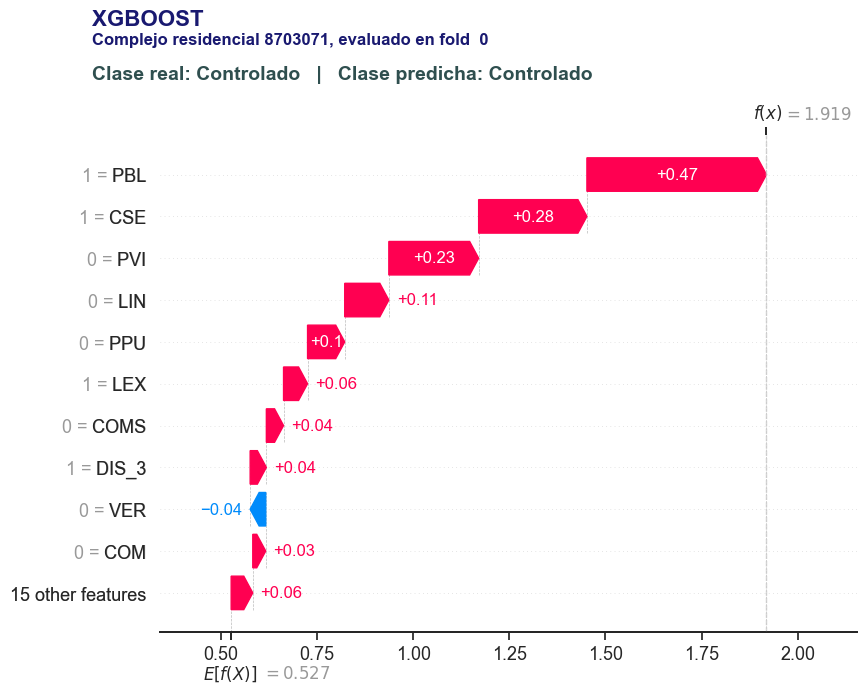

In [15]:
# Set sample ID
id_sample = 8703071
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=130, figsize=[12,6])
plot_shap_waterfall(cfg, LR_pred_info_df, LR_expected_values_df, LR_shap_values_df, id_sample=id_sample, model_name="Logistic Regression", figsize=[9,7])
plot_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

El gráfico waterfall de la regresión logística muestra que la integración en el núcleo urbano (**DIS_3 = 1**), la ausencia de verjas (**VER = 0**) y la ausencia de uso privado de la vía (**PPR = 0**) son las variables que más contribuyen a la clasificación hacia el grado de cerramiento "Simbólico". Aunque estas características son coherentes con una baja intensidad de cerramiento, la presencia de cámaras de seguridad (**CSE = 1**) constituye un elemento asociado a grados de cerramiento más elevados. Sin embargo, en la regresión logística, la contribución de **CSE** únicamente actúa como un factor inhibidor moderado y no resulta suficiente para evitar la clasificación errónea.

En el caso de XGBoost, la explicación de la predicción se apoya principalmente en la presencia de acceso por bloque (**PBL = 1**) y de cámaras de seguridad (**CSE = 1**). Esto se alinea con el grado de cerramiento "Controlado" caracterizado por contar con un cerramiento intenso pero matizado por algún elemento que lo reduce. En este caso la intensidad viene dada por la presencia de cámaras de seguridad y los elementos que contribuyen a reducirla son el acceso por bloque y la integración en el núcleo úrbano.

XGBoost consigue clasificar correctamente dado que utiliza la información de las cámaras de seguridad, mientras que en la regresión logística su  contribución es muy reducida.

El segundo caso corresponde a un complejo residencial “Autoaislado”, cuyo identificador CC es 2201001. Este caso presenta una alta complejidad para los modelos ya que combina características asociadas fuertemente a dos grados de cerramiento diferentes. Por un lado, está aislado del núcleo úrbano (**DIS_1 = 1**), cuenta con calles en fondo de saco (**CFS = 1**) y tiene uso público de la vía (**PPU = 1**) que son características asociadas al grado de cerramiento "Autoaislado". Por otro lado, cuando con cámaras de seguridad (**CSE = 1**) y guardias de seguridad (**GSE = 1**) que tienden a asociarse a los grados de cerramiento "Protegido" y "Controlado".

En este caso, el modelo de regresión logística multinomial realiza una clasificación errónea, asignando el complejo residencial a la categoría "Protegido".

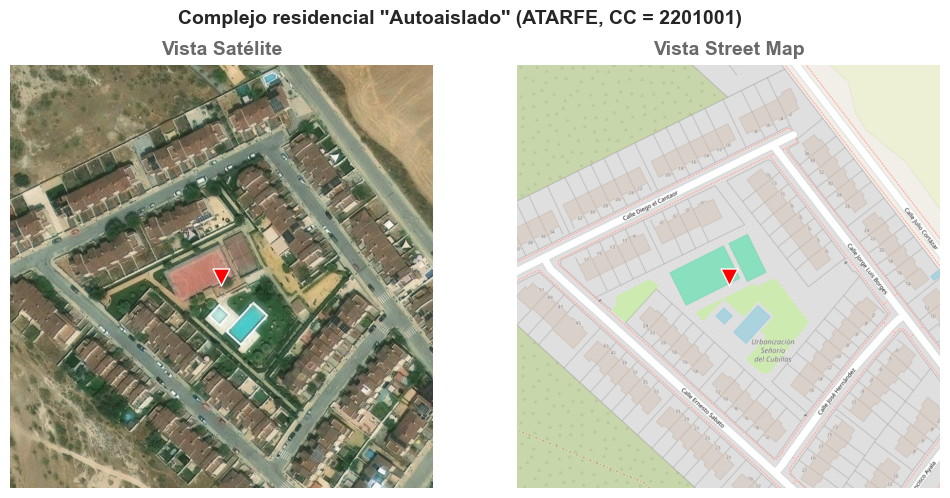

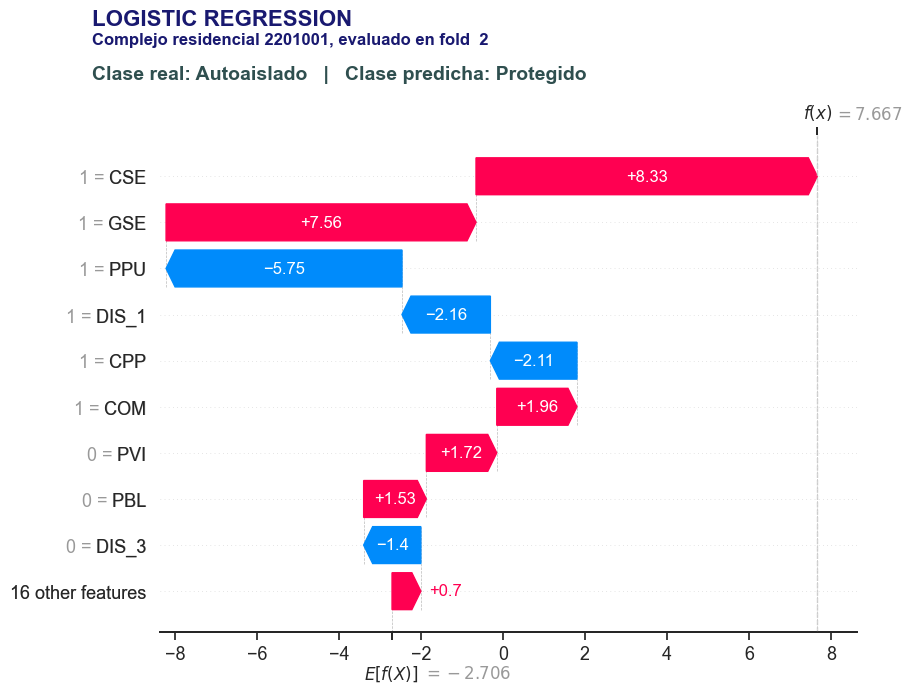

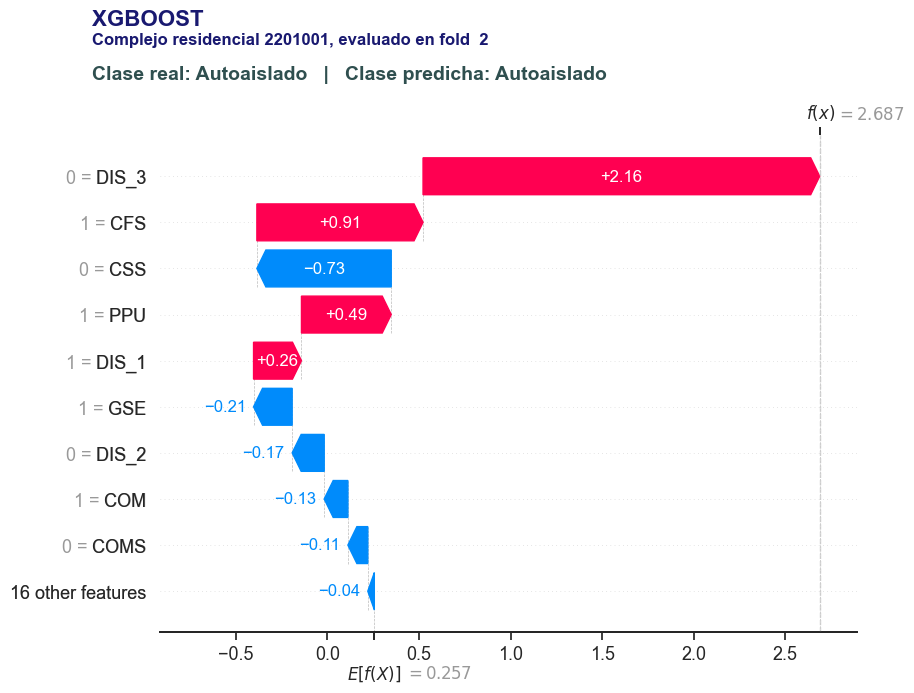

In [13]:
# Set sample ID
id_sample = 2201001
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=130, figsize=[12,6])
plot_shap_waterfall(cfg, LR_pred_info_df, LR_expected_values_df, LR_shap_values_df, id_sample=id_sample, model_name="Logistic Regression", num_features_display=10, figsize=[9,7])
plot_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", num_features_display=10, figsize=[9,7])

En el gráfico waterfall de la regresión logística se observa que la presencia de cámaras de seguridad (**CSE**) y guardias de seguridad (**GSE**) aporta una fuerte contribución hacia la clasificación en el grado de cerramiento "Protegido". Debido a la naturaleza lineal y aditiva del modelo, variables como el uso público de la vía (**PPU = 1**) y el aislamiento respecto al núcleo urbano (**DIS_1 = 1**) actúan como factores inhibidores pero no consiguen compensar la contribución positiva de las variables de seguridad.

En cambio, en la predicción de XGBoost predominan las variables que caracterizan al grado de cerramiento "Autoaislado", principalmente **DIS_1**, **CFS** y **PPU**. Como puede observarse, la presencia de guardias de seguridad únicamente reduce ligeramente la contribución hacia esta clase, mientras que las cámaras de seguridad no aparecen entre las variables más influyentes.

Este comportamiento muestra cómo XGBoost es capaz de contextualizar el efecto de los servicios de seguridad e identificar correctamente que el mecanismo principal de cerramiento es el aislamiento. Aunque los servicios de seguridad estan fuertemente asociadas con el grado de cerramiento "Protegido", las variables que definen el carácter autoaislado del complejo actúan, al mismo tiempo, como factores inhibidores de la clase "Protegido". En la regresión logística, estas variables reducen la contribución hacia la categoría “Protegido”, aunque sin llegar a compensar el peso de las variables asociadas a los servicios de seguridad. En cambio, XGBoost consigue modelar de forma más efectiva este equilibrio entre características contrapuestas, permitiendo que las variables relacionadas con el aislamiento dominen la decisión final.

De este modo, XGBoost no solo consigue realizar una clasificación correcta, sino que además proporciona una explicación coherente y completa reflejando que los servicios de seguridad actúan como elementos complementarios sobre una configuración cuyo mecanismo dominante de cerramiento es el el aislamiento.

A continuación, se analiza el complejo residencial “Simbólico” con identificador CC = 90501001, que constituye un caso de dificultad para la clasificación. Aunque pertenece al grado de cerramiento "Simbólico", el complejo no se encuentra integrado en el núcleo urbano (**DIS_3=0**) y tampoco presenta uso público de la vía (**PPU=0**), debido a la ausencia de viales internos. Ambas características corresponden a variables altamente influyentes en este grado de cerramiento, de acuerdo con el análisis de interpretabilidad global.

En este caso, la regresión logística multinomial clasifica erróneamente la observación como perteneciente al grado de cerramiento "Autoaislado".

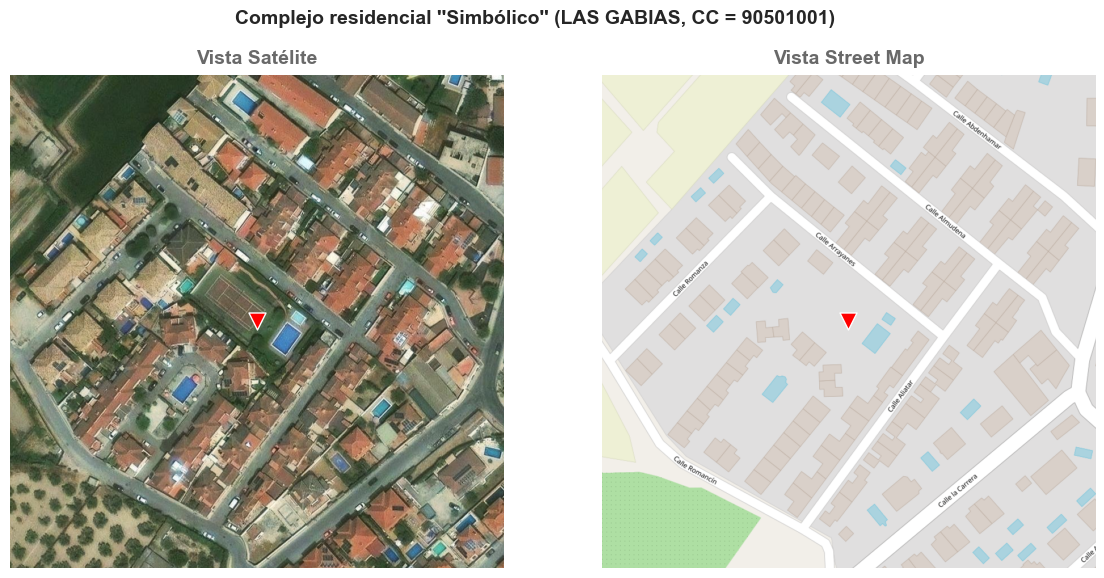

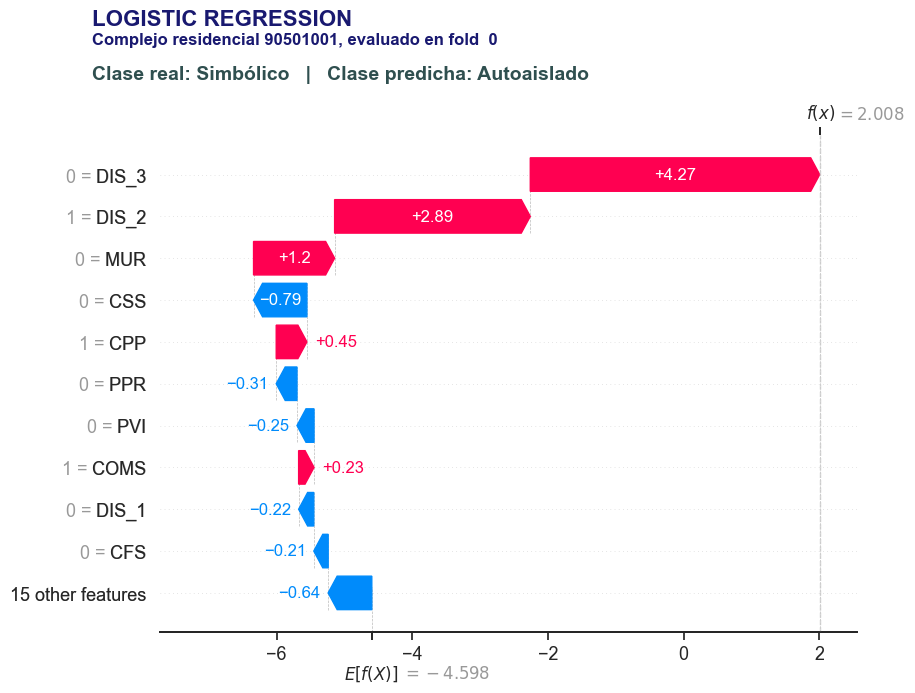

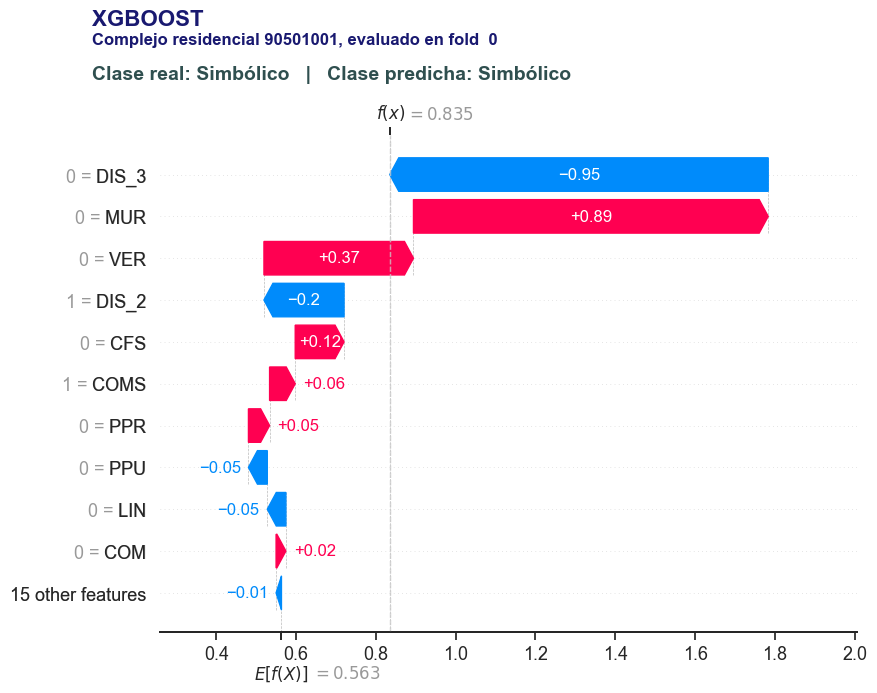

In [14]:
# Set sample ID
id_sample = 90501001
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=130)
plot_shap_waterfall(cfg, LR_pred_info_df, LR_expected_values_df, LR_shap_values_df, id_sample=id_sample, model_name="Logistic Regression",  figsize=[9,7])
plot_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

La predicción realizada por la regresión logística se fundamenta principalmente en la localización geográfica del complejo residencial, al encontrarse separado del núcleo urbano. Como consecuencia, las variables **DIS_3** y **DIS_2** dominan la clasificación hacia el grado de cerramiento “Autoaislado”.
En este caso, la explicabilidad de la predicción queda prácticamente reducida a la no integración en el núcleo urbano, sin que aparezcan otras características de la morfología urbana que puedan asociarse semánticamente con la naturaleza de este nivel de cerramiento.

En el caso de XGBoost, la clasificación se sustenta principalmente en la ausencia de muros (**MUR = 0**) y verjas (**VER = 0**), variables que aportan una contribución positiva hacia la categoría "Simbólico". No obstante, la no integración en el núcleo urbano (**DIS_3 = 0**) actúa como un factor que reduce dicha contribución. Puede observarse que se trata de un caso de elevada complejidad, ya que el complejo residencial presenta pocas características urbanísticas claramente alineadas con el grado de cerramiento "Simbólico".

Sin embargo, a pesar de encontrarse separado del núcleo urbano, el complejo residencial no presenta otras características habitualmente asociadas al grado de cerramiento "Autoaislado", como calles sin salida (**CSS = 0**), calles en fondo de saco (**CFS = 0**) o usuo de la vía de algún tipo (**PPU = 0, PPR = 0, PRE=0**).

XGBoost es capaz reducir la relevancia de la no integración en el núcleo urbano cuando esta no aparece acompañada del resto de variables que configuran el patrón general de la categoría "Autoaislado". Mientras que la naturaleza lineal y aditiva de la regresión logística provoca que la contribución positiva de las variables de aislamiento geográfico tenga un peso dominante frente a la contribución negativa de las variables de elementos disuasorios y de uso de la vía.

Estos casos evidencian como ante casos complejos donde un complejo residencial combina características urbanísticas que pueden cubrir parcialmente patrones generales de diferentes grados de cerramiento, XGBoost explota correctamente estas combinaciones clasificando correctamente y aportando una explicabilidad lógica y coherente con el conocimiento del dominio.

<a id="errores"></a>
## 2.3 Casos erróneos

En esta sección se analizan los casos más conflictivos donde tanto regresión logística como XGBoost clasifican erróneamnete. Este análisis se centra en XGBoost al ser el modelo de mayor complejidad, y el que ha ofrecido tanto mejor rendimiento como mejor explicabilidad.

Se analiza el gráfico *waterfall* de la clase real y de la clase predicha para tener un marco de estudio completo de las variables que alejan de la clasificación correcta y las que lleven hacía la confusión.

Tal y como se presentó en la evaluación de rendimiento, el *recall* obtenido por el modelo XGBoost en las predicciones *out-of-fold* de la validación cruzada anidada es muy elevado en todas las clases a excepción de "Simbólico". En la siguiente tabla se muestra un resumen de estos resultados:

| Grado de cerramiento | recall(%) | Numéro de aciertos | Número de errores |
| --- | --- | --- | --- |
| **Protegido** | 91.9 | 57 | 5 |
| **Controlado** | 99.2 | 259 | 2 |
| **Autoaislado** | 97.3 | 37 | 1 |
| **Individualista** | 100.0 | 213 | 0 |
| **Simbólico** | 72.1 | 49 | 19 |

Como puede observarse, la mayor parte de los errores se concentra en la clase "Simbólico", que ha resultado ser la categoría más conflictiva para todos los modelos evaluados. Entre el resto de grados de cerramiento, destaca la clase "Protegido", con un recall de $\approx92\%$ aunque con un número de errores considerablemente inferior a "Simbólico". Esta sección del análisis estudia un caso representativo de error asociado a la categoría "Protegido" y se centra especialmente en la clase "Simbólico" a través de tres ejemplos representativos que ilustran porque los modelos encuentran una limitación al rendimiento en este grado de cerramiento.

In [10]:
# Select failed cases in both models
fail_cases_df = compare_pred_df[
    (compare_pred_df["URB_LR"]!=compare_pred_df["URB"]) &
    (compare_pred_df["URB_XG"]!=compare_pred_df["URB"])

].copy().reset_index(drop=True)

En primer lugar, se analiza el complejo residencial "Protegido", cuyo identificador CC es 6801002. Se trata de un caso especialmente complejo, ya que, al igual que el complejo "Autoaislado2 con CC = 2201001 analizado en la sección anterior, combina características urbanísticas asociadas tanto al grado de cerramiento "Autoaislado" como al grado "Protegido".

El complejo residencial se caracteriza principalmente por encontrarse separado del núcleo urbano (**DIS_3 = 0**), presentar calles en fondo de saco (**CFS = 1**) y disponer de servicio de guardia de seguridad (**GSE = 1**).

XGBoost clasifica erróneamente esta observación en el grado de cerramiento "Autoaislado"

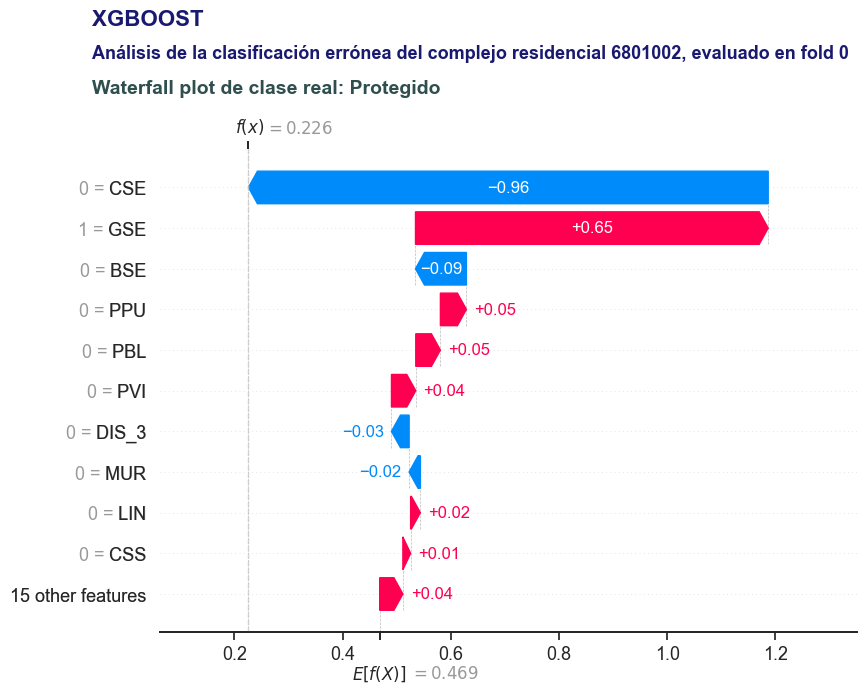

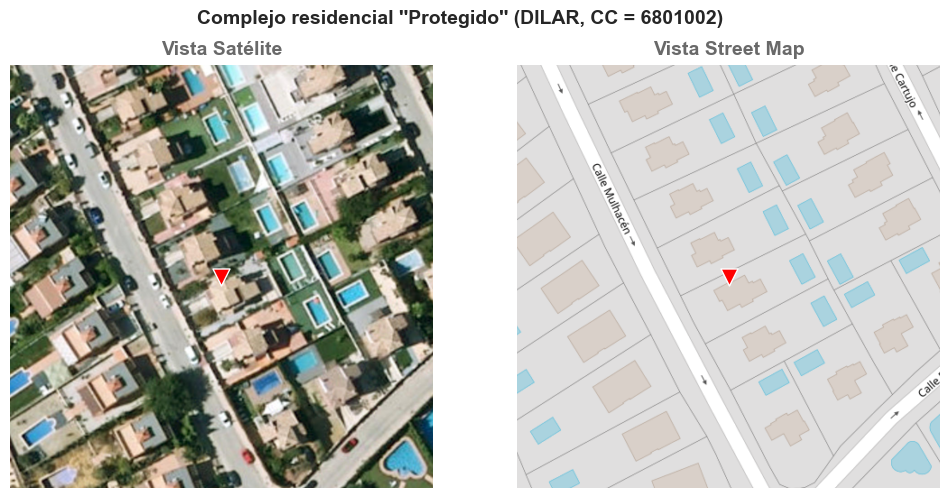

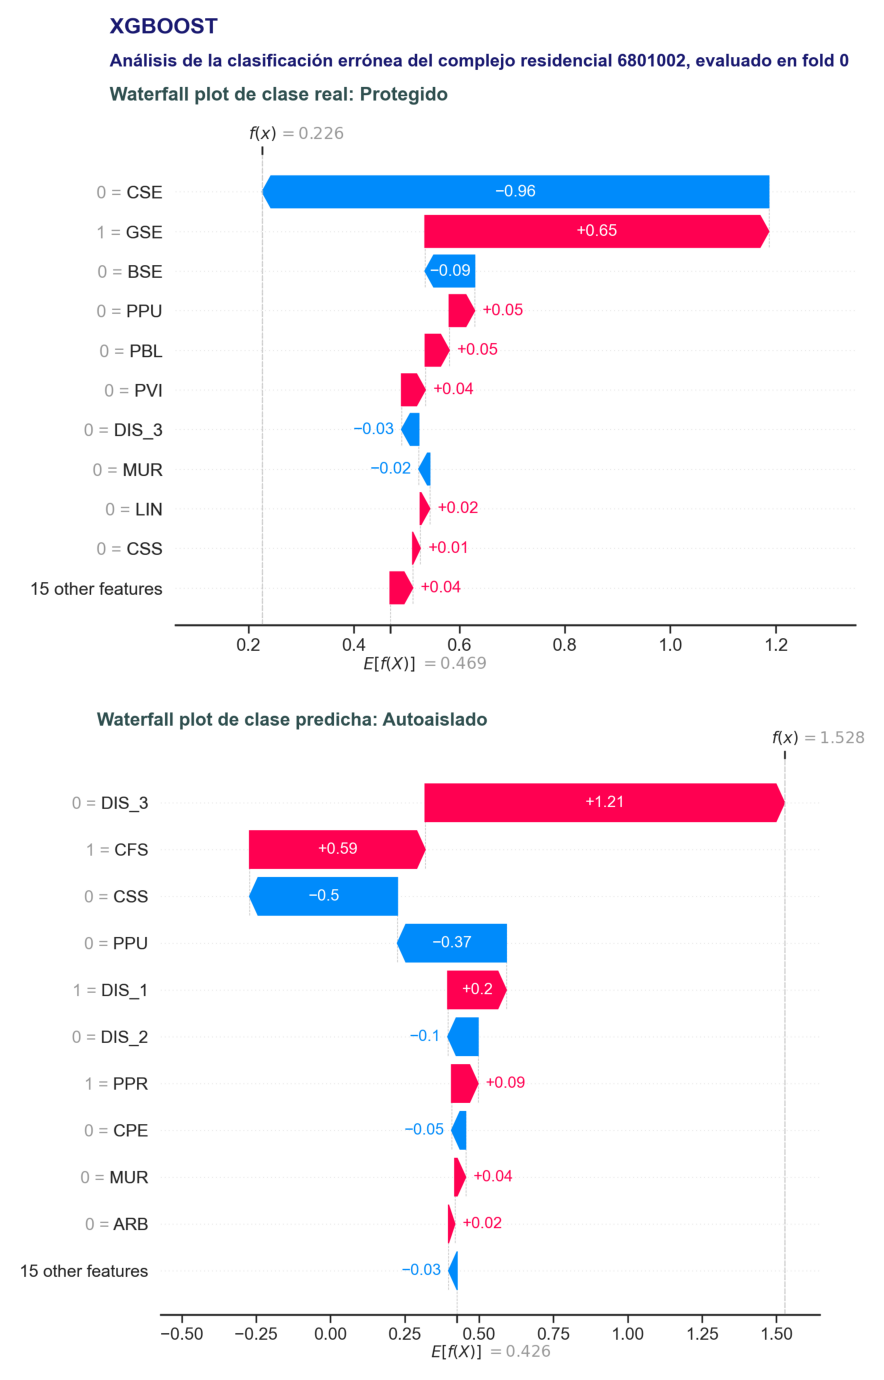

In [14]:
# Set sample ID
id_sample = 6801002
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=70, figsize=[12,6])
plot_misclassification_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

El gráfico waterfall asociado a la clase "Protegido" muestra cómo la contribución positiva de la variable **GSE** se ve anulada por la ausencia de cámaras de seguridad (**CSE = 0**), mientras que el resto de variables que contribuyen positivamente lo hacen de forma discreta. 

Por el contrario, en el gráfico waterfall correspondiente a la clase "Autoaislado", la no integración en el núcleo urbano (**DIS_3 = 0, DIS_1 = 1**) y la presencia de calles en fondo de saco (**CFS = 1**) empujan la predicción hacia dicha categoría. La ausencia de uso público de la vía (**PPU = 0**) y de calles sin salida (**CSS = 0**) son los principales factores inhibidores de esta categoría.

Nos encontramos ante un caso de dificultad elevada, ya que el complejo residencial únicamente presenta un elemento claramente asociado al grado de cerramiento "Protegido", concretamente la presencia de guardia de seguridad (**GSE = 1**). Sin embargo, el resto de sus características urbanísticas se alinean en mayor medida con el patrón típico del grado de cerramiento "Autoaislado", al tratarse de un complejo separado del núcleo urbano, con elementos disuasorios y presencia de viario interno de uso privado.

Puede interpretarse que se trata de un complejo residencial con un modelo de cerramiento híbrido entre "Autoaislado" y "Protegido". El modelo otorga una mayor relevancia a las variables relacionadas con el aislamiento espacial que a la existencia de servicios de seguridad. Este comportamiento resulta coherente con el observado en el complejo residencial CC = 2201001 analizado en la sección anterior, que presenta una morfología urbana muy similar, aunque en su etiqueta real sí corresponde al grado de cerramiento "Autoaislado".

Este comportamiento sugiere una posible inconsistencia en las etiquetas de estos complejos residenciales. Ambos presentan una morfología urbanística muy similar: se encuentran separados del núcleo urbano, cuentan con calles en fondo de saco y disponen de servicios de seguridad. El modelo los clasifica de forma consistente dentro del grado de cerramiento "Autoaislado", mientras que sus etiquetas reales difieren entre sí. Puede concluirse  que se trata de un caso inherentemente complejo desde el punto de vista clasificatorio.

A continuación, se procede a analizar tres errores cometidos por el modelo en complejos residenciales de la clase "Simbólico".

El primero de ellos, con identificador CC = 8703006, se caracteriza por encontrarse integrado en el núcleo urbano (**DIS_3 = 1**), no disponer de uso público de la vía (**PPU = 0**) debido a la ausencia de viales, y presentar cerramientos de tipo duro, como muros (**MUR = 1**) y verjas (**VER = 1**).

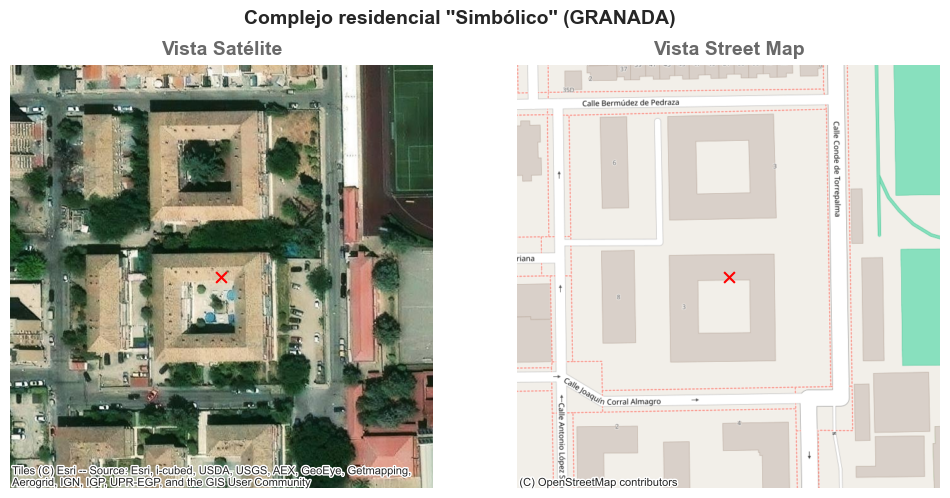

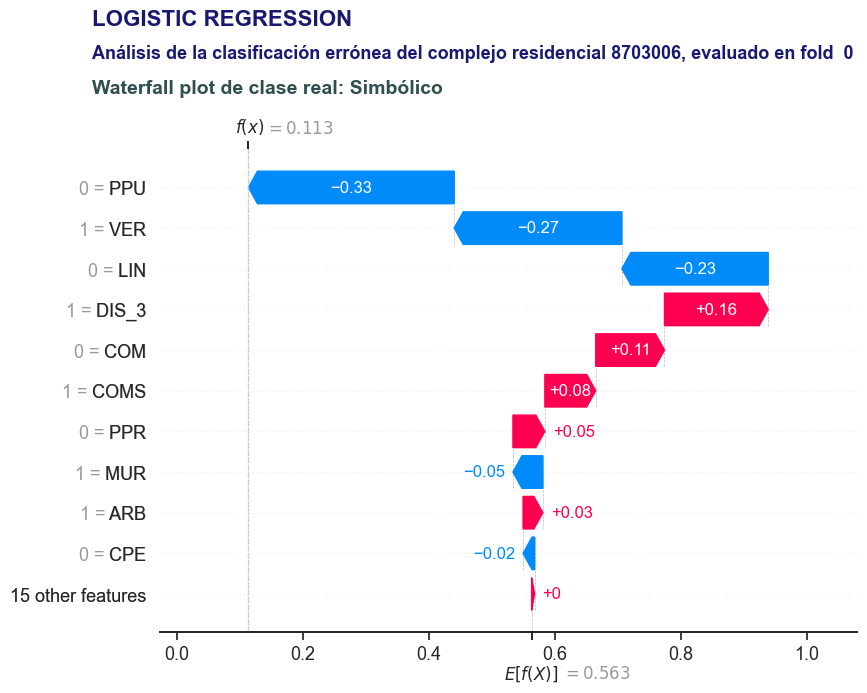

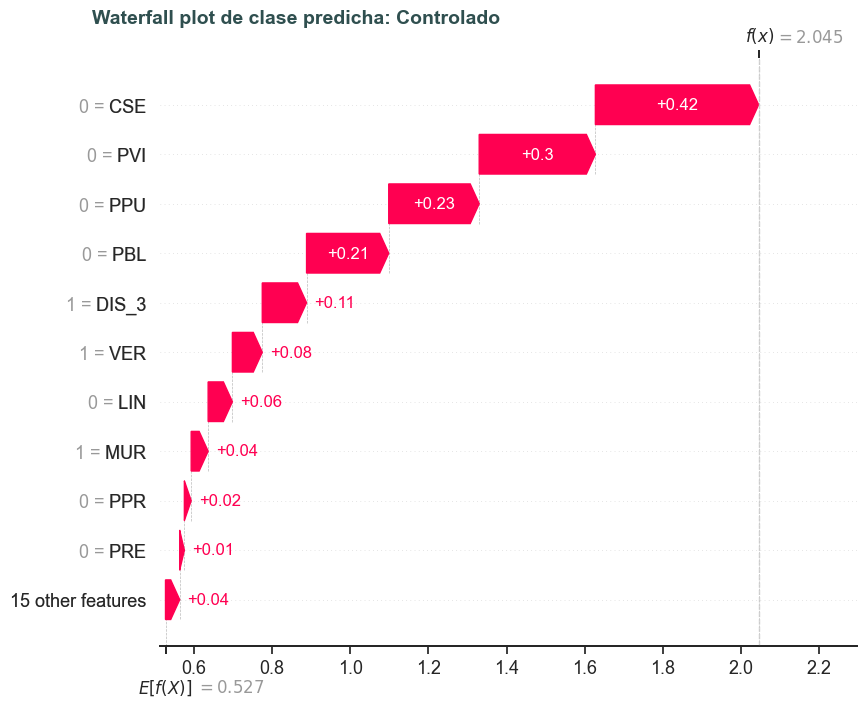

In [ ]:
# Set sample ID
id_sample = 8703006
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=100, figsize=[12,6])
plot_misclassification_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

Como puede observarse en el waterfall plot correspondiente a la clase "Simbólico", la única variable que contribuye de forma positiva es la integración en el núcleo urbano (**DIS_3 = 1**). Por el contrario, la presencia de cerramientos físicos de tipo duro (**MUR = 1, VER = 1**), la ausencia de uso público de la vía (**PPU = 0**) y la ausencia de comercios internos (**LIN = 0**) reducen la contribución hacia esta categoría.

En la predicción asociada a la clase "Controlado", variables como la ausencia de cámaras de seguridad (**CSE = 0**), la ausencia de uso público de la vía (**PPU = 0**) y la ausencia de accesos por bloque (**PBL = 0**) o por vivienda (**PVI = 0**) contribuyen positivamente a la predicción errónea del modelo hacia dicho grado de cerramiento.

Este caso pone de manifiesto la escasa presencia de variables en este complejo residencial que se alineen con el patrón característico del grado de cerramiento "Simbólico", lo que provoca que el modelo se decante por la clase en la que su combinación de variables mejor "encaja", en este caso "Controlado". La interpretación bajo este grado de cerramiento es coherente con la morfología urbana del complejo, ya que, aunque presenta elementos de cerramiento físico, no dispone de servicios de seguridad, lo que sugiere una intensidad de cerramiento intermedia, inferior a la de la categoría "Protegido" y más cercana a "Controlado".

Esto muestra que para este complejo residencial las variables disponibles son insuficientes para caracterizar realmente que su cerramiento es sútil o inexistente y por tanto perteneciente a la categoría "Simbólico". 

El segundo complejo residencial "Simbólico" que se analiza tiene identificador CC=8707014 y ha sido clasificado erróneamente como "Protegido". La particularidad de este complejo residencial es que cuenta con dos servicios de seguridad y carece de variables que se relacionen con el grado de cerramiento "Simbólico".

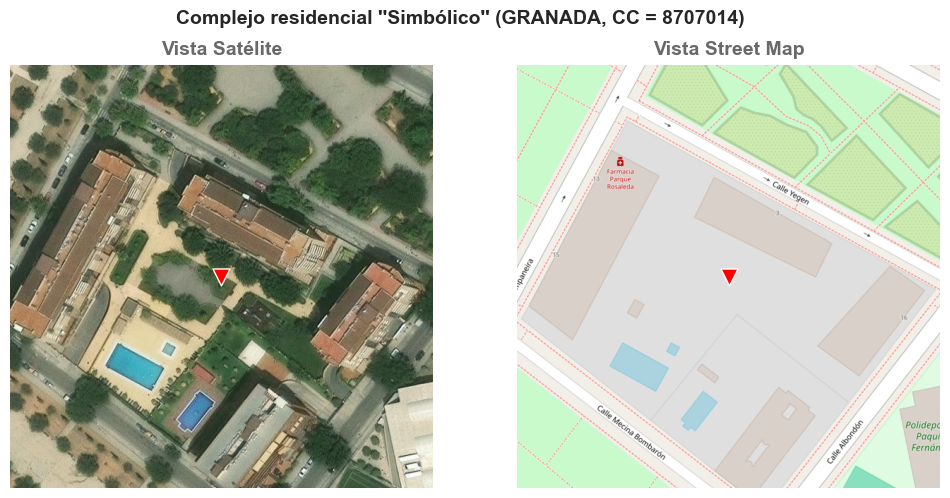

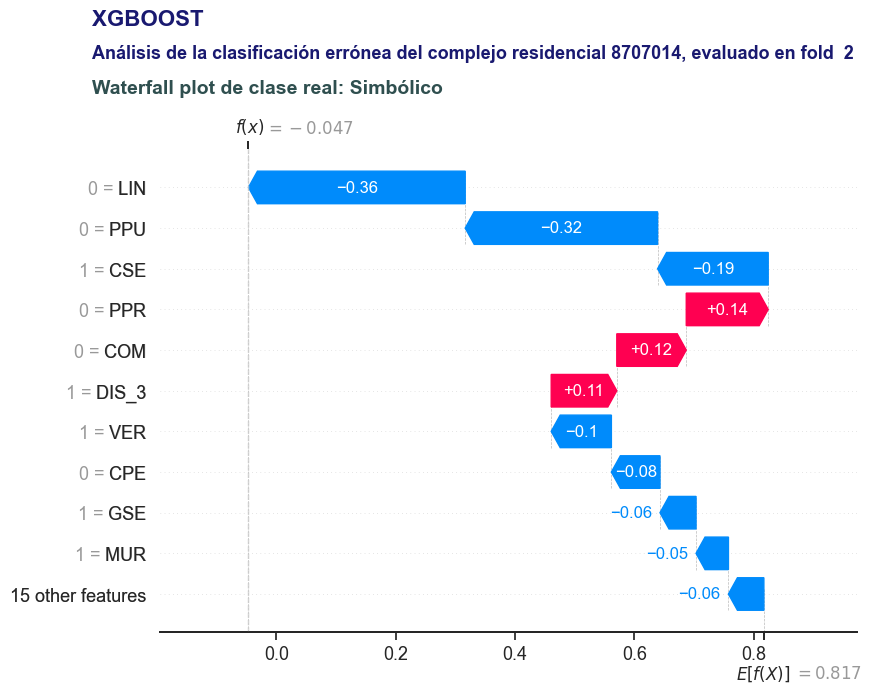

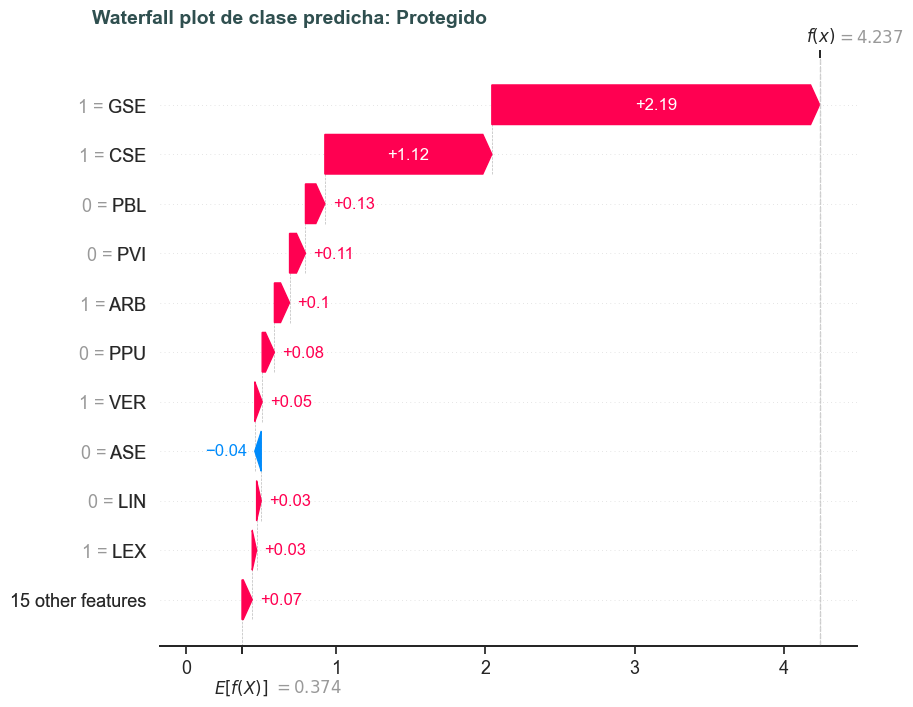

In [19]:
# Set sample ID
id_sample = 8707014
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=100, figsize=[12, 6])
plot_misclassification_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

El gráfico waterfall asociado a la clase “Simbólico” muestra cómo la salida del modelo se reduce de forma notable respecto a la predicción base, debido a la acumulación de contribuciones negativas de un conjunto amplio de variables. Por un lado, la ausencia de características asociadas a este grado de cerramiento, como los comercios internos (**LIN = 0**), uso público de la vía (**PPU = 0**) y las calles peatonales (**CPE = 0**). Por otro lado, la presencia de elementos morfológicos asociados a una mayor intensidad de cerramiento, como las cámaras de seguridad (**CSE = 1**), guardía de seguridad (**GSE = 1**), muros (**MUR = 1** ) y verjas (**VER = 1**). 

Mientras que en el *waterfall* de la clase "Protegido", la presencia de los servicios de seguridad (**CSE = 1, GSE = 1**) domina la predicción con contribuciones muy elevadas.

Atendiendo a las variables disponibles, la clasificación más coherente con lo que el modelo puede inferir es "Protegido". Este caso evidencia que las variables disponibles no logran capturar adecuadamente la naturaleza del grado de cerramiento "Simbólico" en este complejo residencial. En cambio, este patrón de variables urbanísticas se alinea de forma clara y consistente con el patrón característico del grado de cerramiento "Protegido", de acuerdo con las variables que presentan mayor relevancia para este grado de cerramiento (identificadas en el estudio de importancia de variables realizado en el análisis de interpretabilidad global).

Por último, se analiza el complejo residencial "Simbólico" con identificador CC = 14501029, clasificado incorrectamente como "Individualista". Se trata, de nuevo, de un caso conflictivo en el que la morfología urbana del complejo residencial no se alinea de forma clara con los patrones característicos del grado de cerramiento "Simbólico".

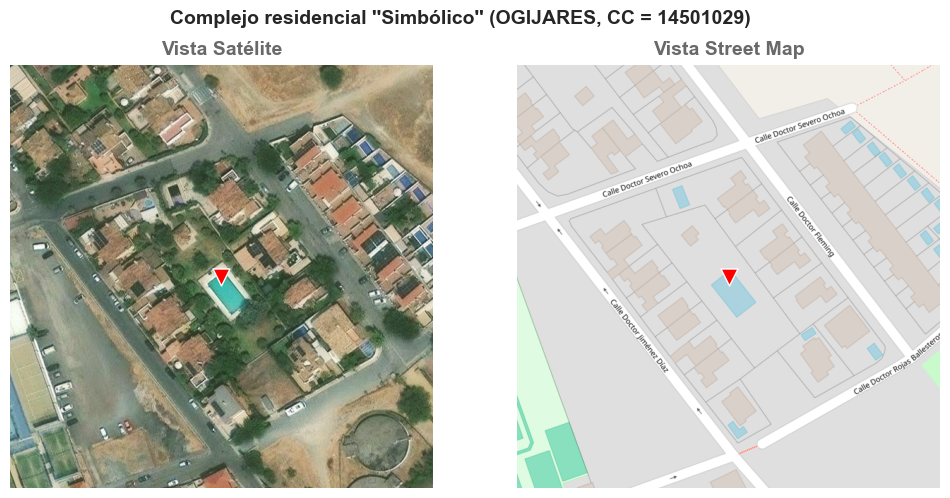

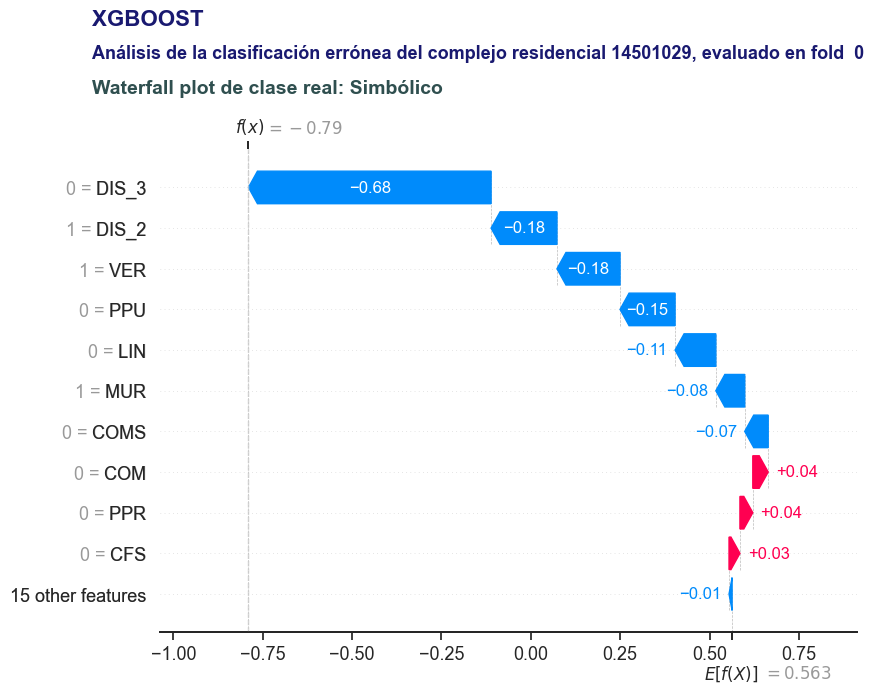

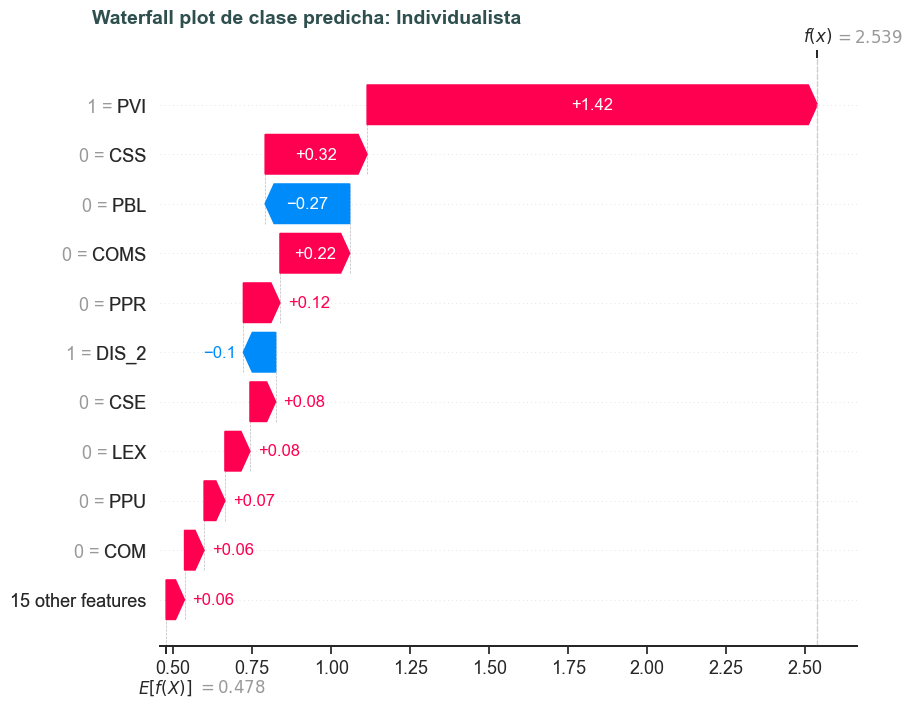

In [20]:
# Set sample ID
id_sample = 14501029
plot_individual_sample_map(cfg, descriptive_data_df, id_sample, half_side=100, figsize=[12,6])
plot_misclassification_shap_waterfall(cfg, XG_pred_info_df, XG_expected_values_df, XG_shap_values_df, id_sample=id_sample, model_name="XGBoost", figsize=[9,7])

El gráfico *waterfall* de la clase "Simbólico" está poblado de factores inhbidores lo que refleja la ausencia de características que contribuyan a este grado de cerramiento. Este complejo residencial no cuenta con ninguno de los factores catalizadores de esta clase, por lo que las variables más influyentes contribuyen de forma negativa. Se trata de un complejo residencial aislado del núcleo úrbano (**DIS_3 = 0, DIS_2=1**), con cerramientos físicos de tipo duro (**MUR=1, VER=1**), sin uso público de la vía (**PPU = 0**) y sin comercios internos (**LIN = 0**).

El modelo clasifica este complejo residencial en el grado de cerramiento "Individualista" debido a que su acceso se realiza a través de vivienda (**PVI = 1**).

Los ejemplos analizados en esta sección representan el principal motivo por el que el modelo presenta un rendimiento más limitado en la clase “Simbólico”, en la que se observa una elevada complejidad estructural y una menor claridad en los patrones discriminativos.


De acuerdo con la caracterización del grado de cerramiento “Simbólico” realizada en el análisis de interpretabilidad global, el modelo identifica este grado de cerramiento a partir de cuatro dimensiones principales:
* Integración en el núcleo urbano.
* Ausencia de cerramientos físicos de tipo duro (muros y verjas).
* Uso público de la vía.
* Presencia de comercios internos.

Aunque este conjunto de variables parece suficientemente amplio como para caracterizar el grado de cerramiento "Simbólico", los resultados de rendimiento muestran que únicamente el $\approx 72%$ de los complejos residenciales etiquetados como "Simbólico" se ajustan a esta morfología urbana, mientras que el $28\%$ restante no queda adecuadamente representado por dichos patrones. El análisis de interpretabilidad local de este $28\%$ de errores pone de manifiesto que el conjunto de variables disponible no es suficiente para clasificar correctamente estos complejos en el grado de cerramiento "Simbólico".

Aunque los comercios internos y la ausencia de cerramientos de tipo duro pueden considerarse las variables más representativas de un cerramiento sutil, su presencia en el conjunto de datos es muy reducida, tal y como se identificó en el análisis exploratorio. La presencia de cerramientos de tipo blando (bolardos, arbustos, carteles de propiedad privada o cadenas) podría aportar información relevante para este grado de cerramiento, sin embargo, en el análisis exploratorio se observó una baja asociación con la clase "Simbólico", además de una frecuencia de aparición igualmente limitada.

Como consecuencia, el modelo es capaz de identificar correctamente los complejos residenciales "Simbólicos" cuando se cumplen algunos de los patrones característicos previamente descritos. Sin embargo, cuando dichas variables no están presentes, el modelo carece de señales suficientes para reconocer esta clase y termina asignando la observación a otro grado de cerramiento. En estos casos, la predicción puede producirse con alta confianza cuando la morfología urbana se alinea claramente con alguno de los grados de cerramiento restantes. No obstante, en otras ocasiones la clasificación es más residual, ya que la observación se asigna a la clase que mejor encaja con la combinación disponible de variables, aunque sin una explicabilidad sólida ni coherente con el conocimiento del dominio.

Las variables predictoras que describen la morfología urbana de este conjunto de datos presentan relación con la intensidad del cerramiento. Sin embargo, la categoría "Simbólico" representa un nivel de cerramiento sutil o incluso inexistente, por lo que dichas variables pueden no ser suficientes para caracterizar de forma clara la ausencia de cerramiento.

Esta conclusión se deriva directamente del análisis de los errores de clasificación del modelo sobre los complejos residenciales "Simbólicos", donde se observa una falta de variables verdaderamente discriminativas para esta categoría.

En consecuencia, una línea de mejora para futuras campañas de recolección de datos consiste en incorporar variables urbanísticas que capturen de forma más directa niveles bajos o inexistentes de cerramiento, reforzando así la capacidad del modelo para identificar este tipo de cerramiento.